# K-means and Silhouette Score

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [3]:
predict_conversion_df = pd.read_csv("digital_marketing_campaign_dataset.csv")
google_ads_df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")
marketing_product_df = pd.read_csv("marketing_and_product_performance.csv")

In [ ]:
# 1. Clean Numeric Strings (Cost, Sale_Amount)
for col in ['Cost', 'Sale_Amount']:
    google_ads_df[col] = google_ads_df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
    google_ads_df[col] = pd.to_numeric(google_ads_df[col], errors='coerce')

# 2. Impute missing values for primary numeric features with the mean
columns_to_impute = ['Cost', 'Sale_Amount', 'Clicks', 'Impressions', 'Leads']
google_ads_df[columns_to_impute] = google_ads_df[columns_to_impute].fillna(google_ads_df[columns_to_impute].mean())

# 3. Standardize Categorical Columns (Unify typos and case)
google_ads_df['Campaign_Name'] = 'Data Analytics Course' 

# Unify Location to 'hyderabad'
google_ads_df['Location'] = 'hyderabad'

# Lowercase Device and Keyword
google_ads_df['Device'] = google_ads_df['Device'].str.lower()
google_ads_df['Keyword'] = google_ads_df['Keyword'].str.lower()

# 4. Standardize and Parse Dates
# Handling multiple formats: YYYY-MM-DD, DD-MM-YYYY, YYYY/MM/DD
google_ads_df['Ad_Date'] = pd.to_datetime(google_ads_df['Ad_Date'], format='mixed', dayfirst=True)

# Extract Date Features
google_ads_df['DayOfWeek'] = google_ads_df['Ad_Date'].dt.dayofweek
google_ads_df['DayOfMonth'] = google_ads_df['Ad_Date'].dt.day

# 5. Recalculate 'Conversion Rate' to handle missing values and maintain logical consistency
google_ads_df['Conversion Rate'] = google_ads_df['Conversions'] / google_ads_df['Clicks']
google_ads_df['Conversion Rate'] = google_ads_df['Conversion Rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Check remaining missing values
print("Remaining missing values in google_ads_df:\n", google_ads_df.isnull().sum())
print("\nCleaned Categorical Samples:")
print(google_ads_df[['Device', 'Ad_Date', 'DayOfWeek']].head())

Remaining missing values in google_ads_df:
 Ad_ID               0
Campaign_Name       0
Clicks              0
Impressions         0
Cost                0
Leads               0
Conversions        74
Conversion Rate     0
Sale_Amount         0
Ad_Date             0
Location            0
Device              0
Keyword             0
DayOfWeek           0
DayOfMonth          0
dtype: int64

Cleaned Categorical Samples:
    Device    Ad_Date  DayOfWeek
0  desktop 2024-11-16          5
1   mobile 2024-11-20          2
2  desktop 2024-11-16          5
3   tablet 2024-11-26          1
4  desktop 2024-11-22          4


C:\Users\santo\AppData\Local\Temp\ipykernel_17144\1740704996.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  google_ads_df[col] = google_ads_df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
C:\Users\santo\AppData\Local\Temp\ipyk

### K-means elbow method for predict_conversion_df

Dataset shape: (8000, 20)

Column names and types:
CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

First few rows:
   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awar

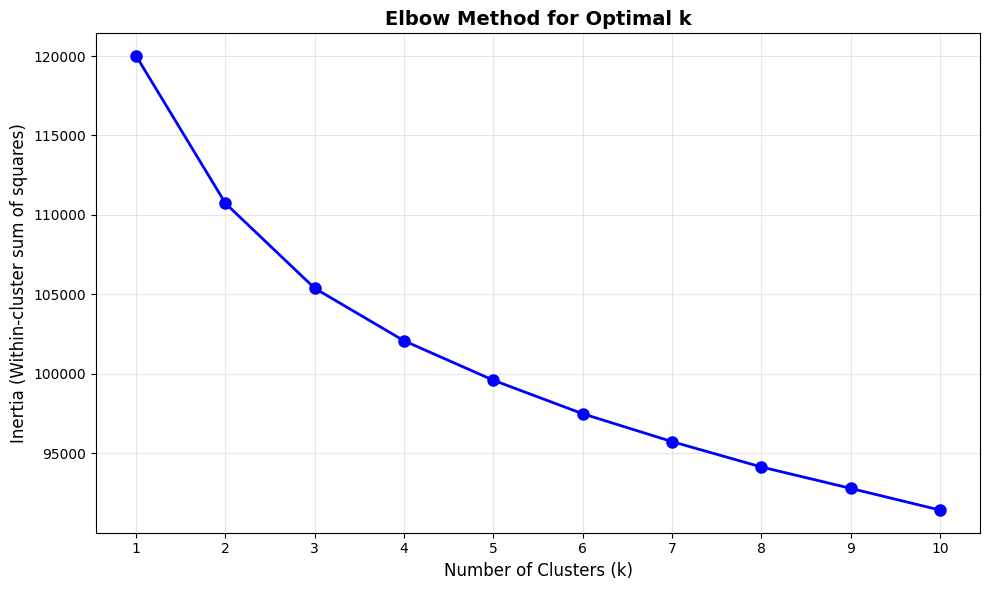


Look for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display info about predict_conversion_df
print("Dataset shape:", predict_conversion_df.shape)
print("\nColumn names and types:")
print(predict_conversion_df.dtypes)
print("\nFirst few rows:")
print(predict_conversion_df.head())

# Select numeric columns for clustering
numeric_cols = predict_conversion_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns selected for clustering: {numeric_cols}")

# Prepare the data
X = predict_conversion_df[numeric_cols].dropna()
print(f"\nData shape after removing NaN: {X.shape}")

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method: Test different values of k
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("\nLook for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.")

The elbow for this dataset appears to be around k=3 or k=4, which is where the rate of decrease in inertia starts to level off. This suggests that 3 to 4 clusters would be the optimal number of segmenting this customer dataset. Adding any more clusters beyond these would not bring greater insights. 

### Silhouette Score for predict_conversion_df

Calculating Silhouette Scores for predict_conversion_df:
K=2, Silhouette Score=0.1653
K=3, Silhouette Score=0.0630
K=4, Silhouette Score=0.0551
K=5, Silhouette Score=0.0540
K=6, Silhouette Score=0.0513
K=7, Silhouette Score=0.0505
K=8, Silhouette Score=0.0509
K=9, Silhouette Score=0.0502
K=10, Silhouette Score=0.0511

Best number of clusters: k=2
Best silhouette score: 0.1653


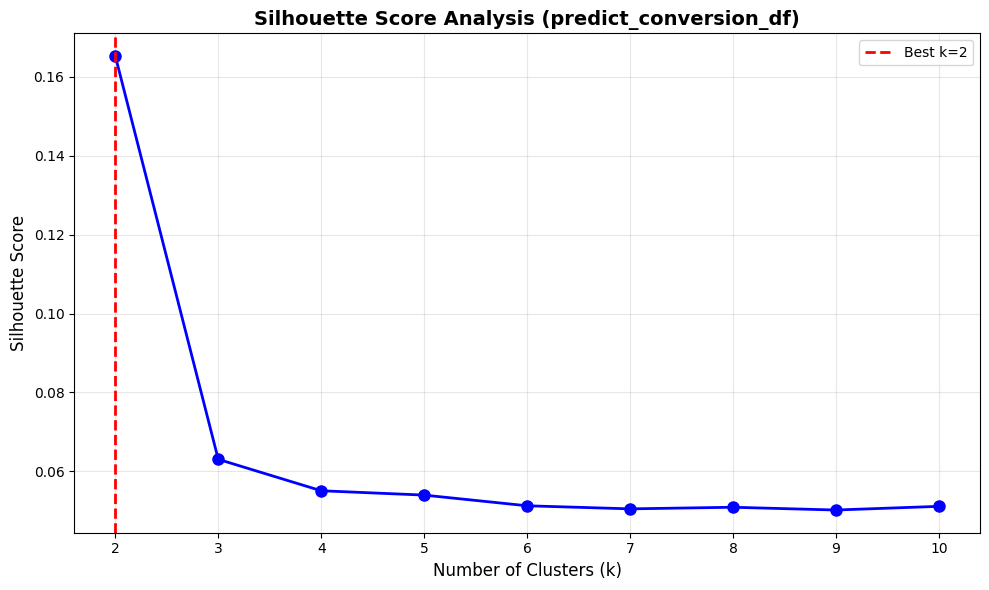


Interpretation:
The optimal number of clusters is k=2 with a silhouette score of 0.1653
This confirms/refines the elbow method suggestion of k=3 or k=4.


In [9]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use the already prepared data from the elbow method
# X_scaled already exists from the previous cell

# Calculate silhouette scores for different k values
silhouette_scores = []
K_range = range(2, 11)  # Silhouette score needs at least 2 clusters

print("Calculating Silhouette Scores for predict_conversion_df:")
print("=" * 60)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}, Silhouette Score={silhouette_avg:.4f}")

# Find the best k
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print("\n" + "=" * 60)
print(f"Best number of clusters: k={best_k}")
print(f"Best silhouette score: {best_score:.4f}")
print("=" * 60)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', linewidth=2, label=f'Best k={best_k}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis (predict_conversion_df)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"The optimal number of clusters is k={best_k} with a silhouette score of {best_score:.4f}")
print(f"This confirms/refines the elbow method suggestion of k=3 or k=4.")

Although the elbow method showed diminsihing returns around 3-4 clusters, the silhouette score reveals that only 2 clusters have actual meaningful separation. These two clusters could be the converted versus non-converters or high-engagement versus low-engagement consumers. 

### K-means elbow method for google_ads_df

Dataset shape: (2600, 15)

Column names and types:
Ad_ID                      object
Campaign_Name              object
Clicks                    float64
Impressions               float64
Cost                      float64
Leads                     float64
Conversions               float64
Conversion Rate           float64
Sale_Amount               float64
Ad_Date            datetime64[ns]
Location                   object
Device                     object
Keyword                    object
DayOfWeek                   int32
DayOfMonth                  int32
dtype: object

First few rows:
   Ad_ID          Campaign_Name  Clicks  Impressions    Cost  Leads  \
0  A1000  Data Analytics Course   104.0       4498.0  231.88   14.0   
1  A1001  Data Analytics Course   173.0       5107.0  216.84   10.0   
2  A1002  Data Analytics Course    90.0       4544.0  203.66   26.0   
3  A1003  Data Analytics Course   142.0       3185.0  237.66   17.0   
4  A1004  Data Analytics Course   156.0       3361.0 

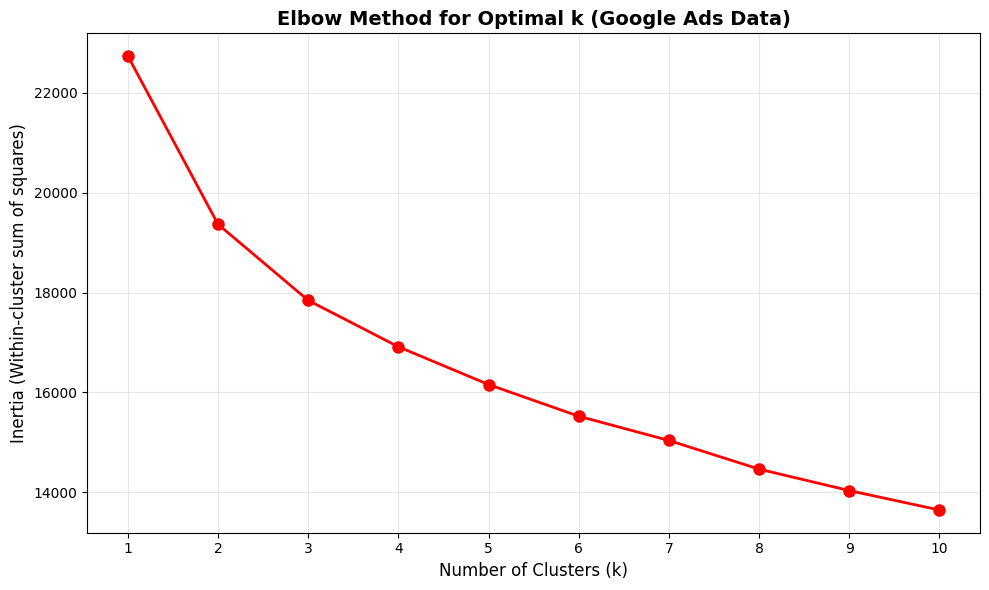


Look for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display info about google_ads_df
print("Dataset shape:", google_ads_df.shape)
print("\nColumn names and types:")
print(google_ads_df.dtypes)
print("\nFirst few rows:")
print(google_ads_df.head())

# Select numeric columns for clustering
numeric_cols_google = google_ads_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns selected for clustering: {numeric_cols_google}")

# Prepare the data
X_google = google_ads_df[numeric_cols_google].dropna()
print(f"\nData shape after removing NaN: {X_google.shape}")

# Standardize the features 
scaler_google = StandardScaler()
X_google_scaled = scaler_google.fit_transform(X_google)

# Elbow Method: Test different values of k
inertias_google = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_google_scaled)
    inertias_google.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias_google, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal k (Google Ads Data)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("\nLook for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.")

Similarly to the previously analyzed dataset, the elbow of google_ads_df is around k=3 or k=4, meaning that the optimal number of clusters for segmenting is 3-4. In the contect of this dataset, the clusters could represent a number of different things. It could be different campaign performance tiers or different advertising strategy groups. 

### Silhouette Score for google_ads_df

Calculating Silhouette Scores for google_ads_df:
K=2, Silhouette Score=0.1368
K=3, Silhouette Score=0.1104
K=4, Silhouette Score=0.1011
K=5, Silhouette Score=0.0981
K=6, Silhouette Score=0.0992
K=7, Silhouette Score=0.0932
K=8, Silhouette Score=0.0973
K=9, Silhouette Score=0.0966
K=10, Silhouette Score=0.0991

Best number of clusters: k=2
Best silhouette score: 0.1368


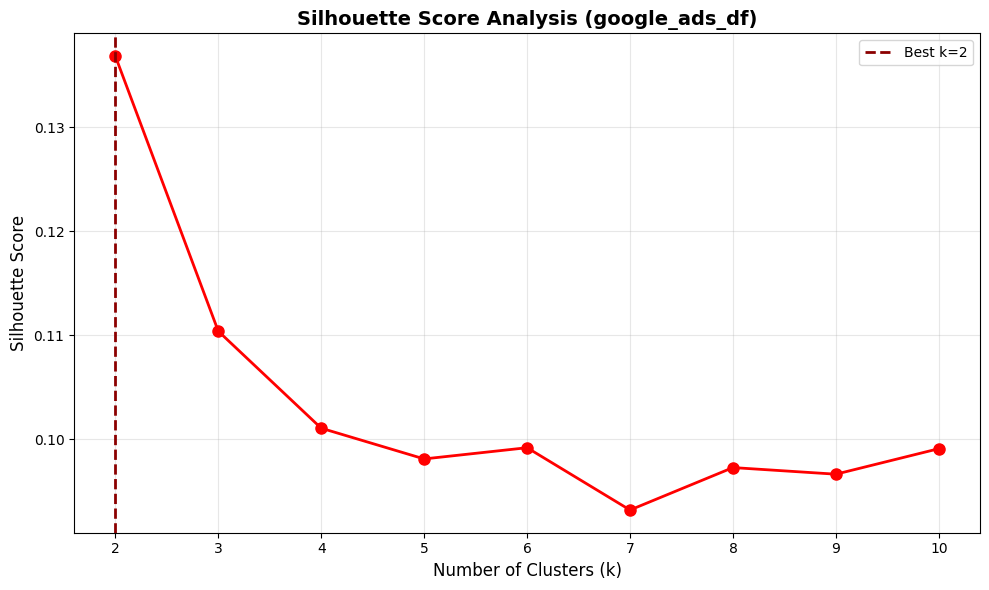


Interpretation:
The optimal number of clusters is k=2 with a silhouette score of 0.1368
This confirms/refines the elbow method suggestion of k=3 or k=4.


In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Use the already prepared data from the elbow method
# X_google_scaled already exists from the previous cell

# Calculate silhouette scores for different k values
silhouette_scores_google = []
K_range = range(2, 11)  # Silhouette score needs at least 2 clusters

print("Calculating Silhouette Scores for google_ads_df:")
print("=" * 60)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_google_scaled)
    silhouette_avg = silhouette_score(X_google_scaled, cluster_labels)
    silhouette_scores_google.append(silhouette_avg)
    print(f"K={k}, Silhouette Score={silhouette_avg:.4f}")

# Find the best k
best_k_google = K_range[silhouette_scores_google.index(max(silhouette_scores_google))]
best_score_google = max(silhouette_scores_google)

print("\n" + "=" * 60)
print(f"Best number of clusters: k={best_k_google}")
print(f"Best silhouette score: {best_score_google:.4f}")
print("=" * 60)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores_google, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=best_k_google, color='darkred', linestyle='--', linewidth=2, label=f'Best k={best_k_google}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis (google_ads_df)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"The optimal number of clusters is k={best_k_google} with a silhouette score of {best_score_google:.4f}")
print(f"This confirms/refines the elbow method suggestion of k=3 or k=4.")

This dataset's silhouette score also revealed that k=2 is significantly higher than k=3 or k=4. These two clusters could represent high versus low performing campaigns or high versus low cost strategies. 

### K-means elbow method for marketing_product_df

Dataset shape: (10000, 17)

Column names and types:
Campaign_ID                           object
Product_ID                            object
Budget                               float64
Clicks                                 int64
Conversions                            int64
Revenue_Generated                    float64
ROI                                  float64
Customer_ID                           object
Subscription_Tier                     object
Subscription_Length                    int64
Flash_Sale_ID                         object
Discount_Level                         int64
Units_Sold                             int64
Bundle_ID                             object
Bundle_Price                         float64
Customer_Satisfaction_Post_Refund      int64
Common_Keywords                       object
dtype: object

First few rows:
  Campaign_ID   Product_ID    Budget  Clicks  Conversions  Revenue_Generated  \
0  CMP_RLSDVN  PROD_HBJFA3  41770.45    4946           73           1552

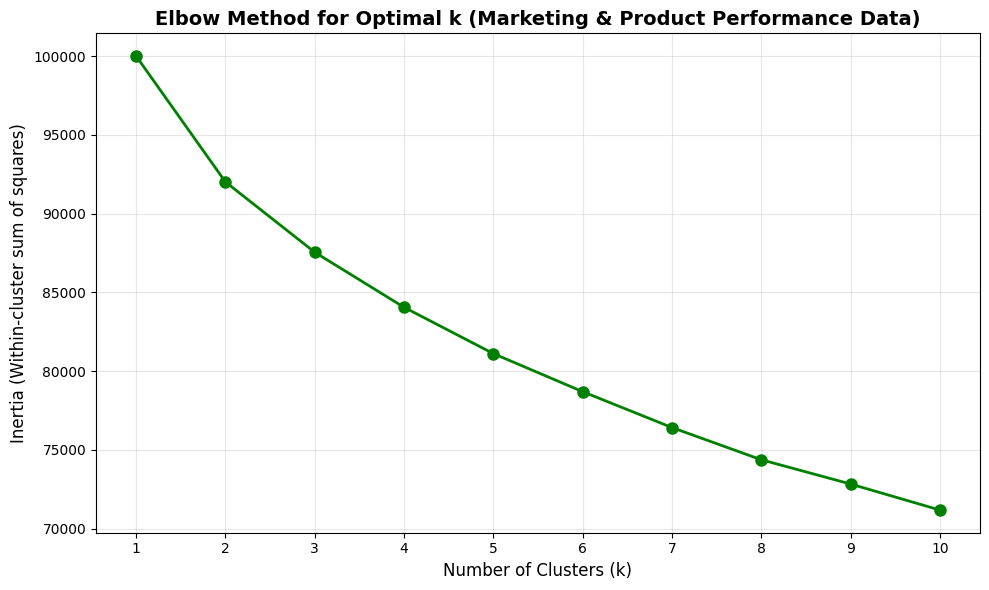


Look for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display info about marketing_product_df
print("Dataset shape:", marketing_product_df.shape)
print("\nColumn names and types:")
print(marketing_product_df.dtypes)
print("\nFirst few rows:")
print(marketing_product_df.head())

# Select numeric columns for clustering
numeric_cols_marketing = marketing_product_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns selected for clustering: {numeric_cols_marketing}")

# Prepare the data
X_marketing = marketing_product_df[numeric_cols_marketing].dropna()
print(f"\nData shape after removing NaN: {X_marketing.shape}")

# Standardize the features 
scaler_marketing = StandardScaler()
X_marketing_scaled = scaler_marketing.fit_transform(X_marketing)

# Elbow Method: Test different values of k
inertias_marketing = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_marketing_scaled)
    inertias_marketing.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias_marketing, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal k (Marketing & Product Performance Data)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("\nLook for the 'elbow' in the plot - the point where the rate of decrease sharply shifts.")

The ideal number of clusters for marketing_product_df is also between 3-4 clusters, as it is where the curve begins to flatten. The different clusters could represent different product performance levels, customer engagement levels, or it could be based on ROI, customer satisfaction, or revenue generation. 

### Silhouette Score for marketing_product_df

Calculating Silhouette Scores for marketing_product_df:
K=2, Silhouette Score=0.0797
K=3, Silhouette Score=0.0662
K=4, Silhouette Score=0.0662
K=5, Silhouette Score=0.0658
K=6, Silhouette Score=0.0657
K=7, Silhouette Score=0.0678
K=8, Silhouette Score=0.0691
K=9, Silhouette Score=0.0686
K=10, Silhouette Score=0.0701

Best number of clusters: k=2
Best silhouette score: 0.0797


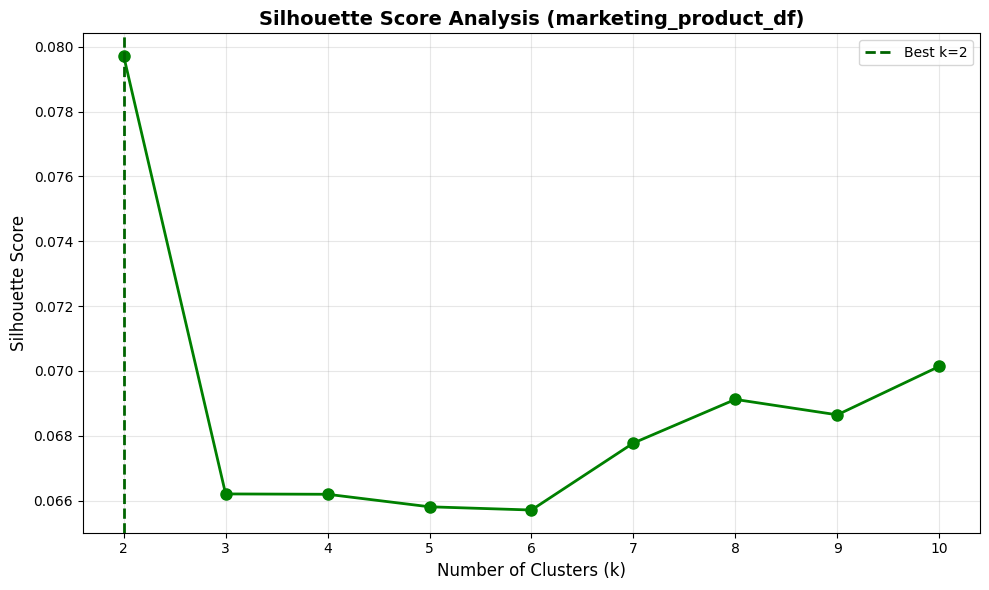


Interpretation:
The optimal number of clusters is k=2 with a silhouette score of 0.0797
This confirms/refines the elbow method suggestion of k=3 or k=4.


In [11]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Use the already prepared data from the elbow method
# X_marketing_scaled already exists from the previous cell

# Calculate silhouette scores for different k values
silhouette_scores_marketing = []
K_range = range(2, 11)  # Silhouette score needs at least 2 clusters

print("Calculating Silhouette Scores for marketing_product_df:")
print("=" * 60)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_marketing_scaled)
    silhouette_avg = silhouette_score(X_marketing_scaled, cluster_labels)
    silhouette_scores_marketing.append(silhouette_avg)
    print(f"K={k}, Silhouette Score={silhouette_avg:.4f}")

# Find the best k
best_k_marketing = K_range[silhouette_scores_marketing.index(max(silhouette_scores_marketing))]
best_score_marketing = max(silhouette_scores_marketing)

print("\n" + "=" * 60)
print(f"Best number of clusters: k={best_k_marketing}")
print(f"Best silhouette score: {best_score_marketing:.4f}")
print("=" * 60)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores_marketing, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k_marketing, color='darkgreen', linestyle='--', linewidth=2, label=f'Best k={best_k_marketing}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis (marketing_product_df)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"The optimal number of clusters is k={best_k_marketing} with a silhouette score of {best_score_marketing:.4f}")
print(f"This confirms/refines the elbow method suggestion of k=3 or k=4.")

Surprisingly, this dataset also had the best silhouette score at k=2. These clusters could represent high versus low ROI, differernt subscription tiers, or engaged vs unengaged customers.